IMPORTs

In [ ]:
import numpy as np
from scipy.special import softmax
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

Data Input

In [3]:
input_1 = np.array([1, 0, 1], dtype=np.float32) # king
input_2 = np.array([0, 2, 0], dtype=np.float32) # queen
input_3 = np.array([-1, -1, 1], dtype=np.float32) # Mobile

Vector Visualization

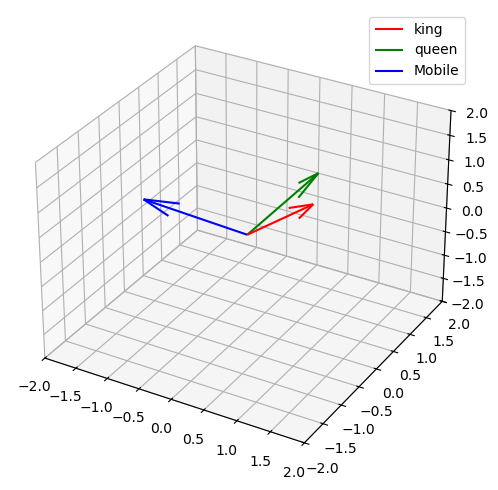

In [6]:
fig = plt.figure()
fig.set_size_inches(8, 6)
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0, 0, 0, 1 ,0, 1, color='r', label='king')
ax.quiver(0, 0, 0, 0 ,2, 0, color='g', label='queen')
ax.quiver(0, 0, 0, -1 ,-1, 1, color='b', label='Mobile')
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])
ax.legend()
plt.show()

Initializing Q,K,V Matrices

In [7]:
wq = np.array([[1, 0, 1],
               [1, 2, 0],
               [0, 0, 1],
               ])


In [8]:
wk = np.array([[0, 0, 1],
               [1, 1, 0],
               [0, 1, 0],
               ])


In [9]:
wv = np.array([[0, 1, 0],
               [0, 4, 0],
               [1, 0, 2],
               ])

In [13]:
print(input_1.dot(wq))
print(input_2.dot(wk))
print(input_3.dot(wv))

[1. 0. 2.]
[2. 2. 0.]
[ 1. -5.  2.]


In [15]:
inputs = np.vstack([input_1, input_2, input_3])
inputs

array([[ 1.,  0.,  1.],
       [ 0.,  2.,  0.],
       [-1., -1.,  1.]], dtype=float32)

In [16]:
print(inputs.dot(wq))

[[ 1.  0.  2.]
 [ 2.  4.  0.]
 [-2. -2.  0.]]


Calculate Representations for Q,K,V

In [17]:
query_rep = inputs.dot(wq)
key_rep = inputs.dot(wk)
value_rep = inputs.dot(wv)

In [18]:
query_rep_dim = np.array([float(query_rep.shape[0])**0.5], dtype=np.float32)

In [19]:
query_rep_dim

array([1.7320508], dtype=float32)

In [21]:
step_1 = query_rep.dot(key_rep.transpose()) / query_rep_dim
step_2 = step_1/ query_rep_dim
step_1
step_2

array([[ 0.66666669,  0.66666669, -1.00000004],
       [ 1.33333338,  4.00000014, -0.66666669],
       [-0.66666669, -2.66666676,  0.66666669]])

In [25]:
attn_score_softmax = softmax(step_2, axis=1)
print(attn_score_softmax)

[[0.45685557 0.45685557 0.08628887]
 [0.06440289 0.92688112 0.00871598]
 [0.20288077 0.02745692 0.7696623 ]]


In [26]:
attn_score_softmax.shape

(3, 3)

In [27]:
value_rep.shape

(3, 3)

Calculate Attention

In [28]:
attention_final = attn_score_softmax.dot(value_rep)
attention_final

array([[ 0.54314443,  3.68025578,  1.08628887],
       [ 0.07311888,  7.43587197,  0.14623775],
       [ 0.97254308, -3.42577535,  1.94508615]])

Text(0.5, 1.0, 'Attention Weights')

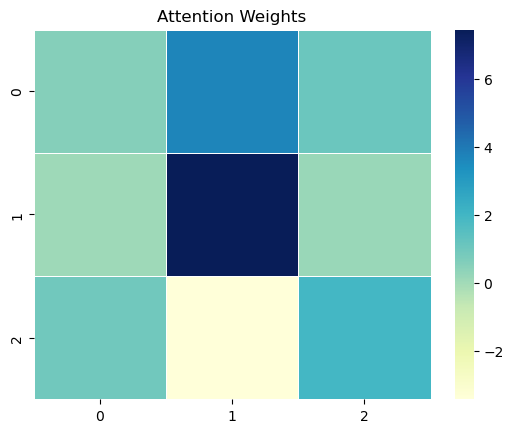

In [30]:
ax = sns.heatmap(attention_final, linewidth= 0.5, cmap="YlGnBu")
ax.set_title("Attention Weights")
